# United States — F-Score grid study: basket k = 30, random draws = 2000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from the
team-computed workbook (`data/processed/`, exact Piotroski conventions,
financial firms removed); prices from the cached Yahoo data. Formations are
July 1 of **2003-2025** (23 chained holding years) using score year T-1 —
one conservative timing rule for both markets; the first scoreable workbook
year is 2002 (the 2000/2001 sheets have no scoreable firms since the panel
needs t-1 and t-2 history), so 2000-2002 formations cannot exist. The
evaluation window ends 2025-12-31. Note the panel resolves to *currently
listed* Yahoo symbols, so the early-2000s universe is survivorship-tilted —
disclosed as a data limitation. The value control falls back to the universe
in years before B/M coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; denoised (not detoned) GMV;
primary measure fixed in advance = net-of-cost Sharpe (20 bp per side,
rf = 0); and the synergy test D = Sharpe(GMV) − Sharpe(EW) computed per
basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.team_scores import load_team_scores, sectors_from_scores
from fscore.grid import run_grid

MARKET, K, N_MC = "us", 30, 2000
YEARS = list(range(2003, 2026))
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "us_k30_mc2000"

scores = load_team_scores(MARKET, ROOT / "data")
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,overlap_random_vs_fscore,overlap_expected
year,,,,,,,,,,,
2003,45,11,0,30,True,45,2,5.222,5.0,0.667,0.667
2004,50,11,0,30,True,50,10,6.400,6.0,0.600,0.600
2005,52,11,0,30,True,52,15,6.558,6.0,0.577,0.577
2006,54,8,0,30,True,54,10,6.111,6.0,0.557,0.556
2007,48,6,0,30,True,48,10,6.479,6.0,0.623,0.625
2008,50,4,0,30,True,50,5,6.180,6.0,0.600,0.600
2009,51,3,34,30,False,30,8,5.922,6.0,0.588,0.588
2010,53,3,43,30,False,30,4,5.755,5.0,0.566,0.566
2011,65,3,52,30,False,30,18,6.508,7.0,0.460,0.462


### 1. Summary (primary measure: net-of-cost Sharpe; rf = 0, costs 20 bp per side on one-way turnover)

In [2]:
summary = study.summary()
summary.round(3)

,cum_return,ann_return,ann_vol,sharpe,max_drawdown,net_ann_return,net_sharpe
fscore_EW,9.585,0.111,0.176,0.633,-0.497,0.109,0.621
fscore_GMV,4.141,0.076,0.149,0.508,-0.369,0.074,0.494
fscore_GMVsec,6.025,0.091,0.153,0.595,-0.394,0.089,0.581
fscore_high_EW,11.169,0.118,0.186,0.633,-0.389,0.116,0.622
value_EW,11.154,0.118,0.180,0.655,-0.521,0.116,0.643
universe_EW,11.673,0.120,0.176,0.683,-0.521,0.118,0.671
universe_GMV,4.810,0.082,0.146,0.559,-0.365,0.080,0.545


### 2. Yearly returns (July–June holding years; final year ends Dec 2025)

In [3]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV
date,,,,,,,
2003,18.9,7.6,14.0,51.6,20.8,20.8,8.9
2004,12.1,14.7,21.4,1.4,15.5,15.5,14.5
2005,7.5,9.1,8.7,8.7,6.9,6.9,4.3
2006,22.1,14.3,23.4,15.4,21.9,21.9,15.2
2007,8.7,14.9,10.4,18.8,9.9,9.9,15.8
2008,-30.3,-20.2,-23.7,-21.9,-32.4,-32.4,-17.8
2009,37.9,21.4,24.4,33.3,34.2,35.7,12.0
2010,12.3,8.4,15.2,10.7,14.5,15.1,12.1
2011,2.9,14.3,13.7,8.0,9.4,5.4,17.7


### 3. Placement vs the random distributions

In [4]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            rows[(label, stat)] = study.placement("fscore_EW", pool, stat)
placement = pd.DataFrame(rows).T
placement.round(3)

percentile  p_value  n_draws  \
random (full universe)     sharpe           0.174    0.826   2000.0   
                           ann_return       0.108    0.892   2000.0   
random (non-F-Score names) sharpe           0.000    1.000   2000.0   
                           ann_return       0.000    1.000   2000.0   

                                       random_mean  random_std  fscore  
random (full universe)     sharpe            0.672       0.042   0.633  
                           ann_return        0.120       0.007   0.111  
random (non-F-Score names) sharpe            0.828       0.037   0.633  
                           ann_return        0.137       0.006   0.111

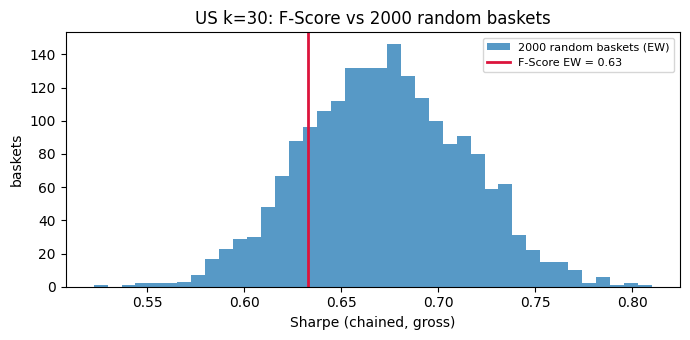

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
fs = placement.loc[("random (full universe)", "sharpe"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_mc_hist.png", dpi=300)
plt.show()

### 4. Synergy test (reviewer priority 1): per-basket optimisation gain D = Sharpe(GMV) − Sharpe(EW)

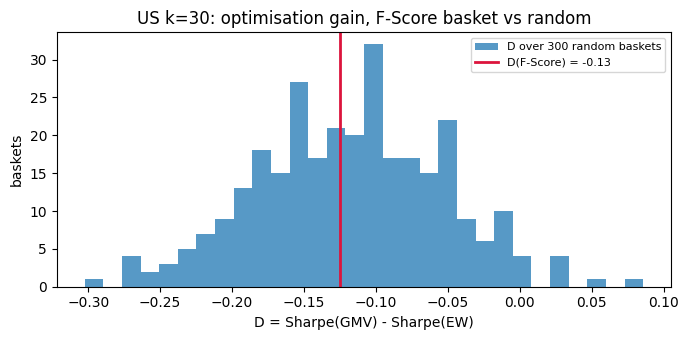

percentile         0.453
p_value            0.547
n_draws          300.000
random_mean       -0.118
random_std         0.065
D_fscore          -0.125
D_random_mean     -0.118
D_random_std       0.065
n                300.000
dtype: float64

In [6]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_synergy_hist.png", dpi=300)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

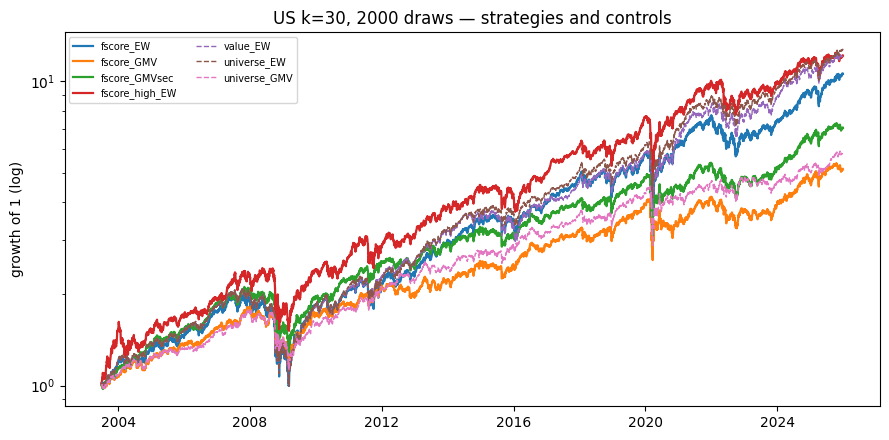

saved us_k30_mc2000


In [7]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_nav.png", dpi=300)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)